In [1]:
!pip install ultralytics


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys

print(sys.executable)

c:\Users\bhanu\Downloads\StructCompose\venv\Scripts\python.exe


In [3]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\bhanu\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
model = YOLO("yolov8n.pt")

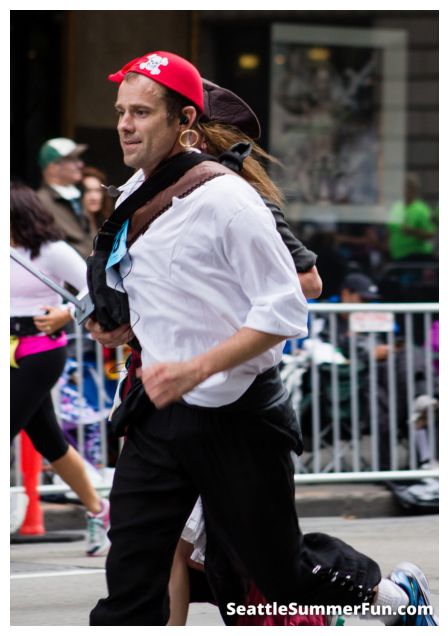

In [10]:
IMAGE_DIR = r"C:\Users\bhanu\Downloads\StructCompose\data\raw\CADB\images"

image_name = "127.jpg"

image_path = os.path.join(IMAGE_DIR, image_name)

img = cv2.imread(image_path)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,8))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

In [11]:
results = model(image_path)


image 1/1 C:\Users\bhanu\Downloads\StructCompose\data\raw\CADB\images\127.jpg: 640x448 5 persons, 124.0ms
Speed: 3.1ms preprocess, 124.0ms inference, 14.6ms postprocess per image at shape (1, 3, 640, 448)


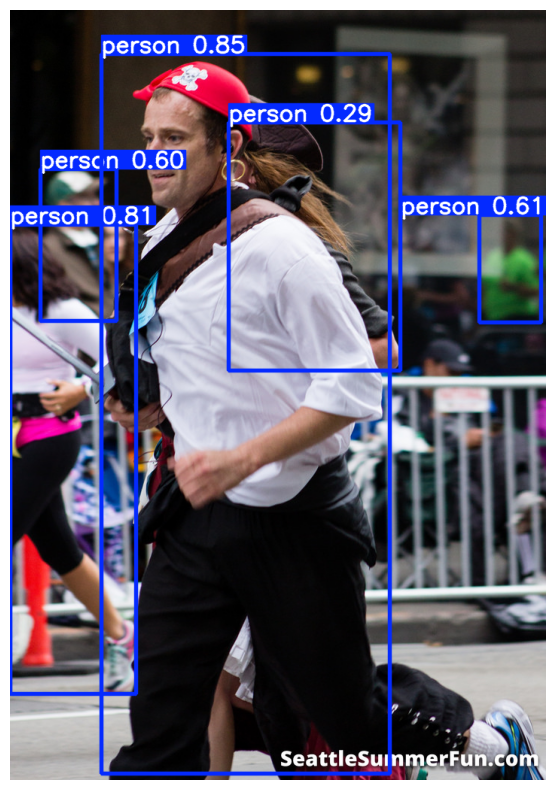

In [12]:
annotated = results[0].plot()

annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,10))
plt.imshow(annotated)
plt.axis("off")
plt.show()

In [13]:
boxes = results[0].boxes

detections = []

for box in boxes:

    cls_id = int(box.cls[0])

    class_name = model.names[cls_id]

    confidence = float(box.conf[0])

    coords = box.xyxy[0].cpu().numpy()

    x1, y1, x2, y2 = coords

    detections.append({
        "class": class_name,
        "confidence": confidence,
        "x1": x1,
        "y1": y1,
        "x2": x2,
        "y2": y2
    })

detections

[{'class': 'person',
  'confidence': 0.8513220548629761,
  'x1': np.float32(121.10225),
  'y1': np.float32(58.31953),
  'x2': np.float32(504.31744),
  'y2': np.float32(1015.34705)},
 {'class': 'person',
  'confidence': 0.8050627112388611,
  'x1': np.float32(0.0),
  'y1': np.float32(285.32013),
  'x2': np.float32(167.70773),
  'y2': np.float32(909.53955)},
 {'class': 'person',
  'confidence': 0.6071149706840515,
  'x1': np.float32(623.2411),
  'y1': np.float32(272.96558),
  'x2': np.float32(705.8882),
  'y2': np.float32(415.89096)},
 {'class': 'person',
  'confidence': 0.5950854420661926,
  'x1': np.float32(40.05102),
  'y1': np.float32(211.72372),
  'x2': np.float32(141.34187),
  'y2': np.float32(413.16522)},
 {'class': 'person',
  'confidence': 0.2924439311027527,
  'x1': np.float32(290.02765),
  'y1': np.float32(149.40817),
  'x2': np.float32(518.80927),
  'y2': np.float32(479.8515)}]

In [14]:
for det in detections:

    cx = (det["x1"] + det["x2"]) / 2
    cy = (det["y1"] + det["y2"]) / 2

    det["center_x"] = cx
    det["center_y"] = cy

detections

[{'class': 'person',
  'confidence': 0.8513220548629761,
  'x1': np.float32(121.10225),
  'y1': np.float32(58.31953),
  'x2': np.float32(504.31744),
  'y2': np.float32(1015.34705),
  'center_x': np.float32(312.70984),
  'center_y': np.float32(536.8333)},
 {'class': 'person',
  'confidence': 0.8050627112388611,
  'x1': np.float32(0.0),
  'y1': np.float32(285.32013),
  'x2': np.float32(167.70773),
  'y2': np.float32(909.53955),
  'center_x': np.float32(83.85387),
  'center_y': np.float32(597.4298)},
 {'class': 'person',
  'confidence': 0.6071149706840515,
  'x1': np.float32(623.2411),
  'y1': np.float32(272.96558),
  'x2': np.float32(705.8882),
  'y2': np.float32(415.89096),
  'center_x': np.float32(664.56464),
  'center_y': np.float32(344.42828)},
 {'class': 'person',
  'confidence': 0.5950854420661926,
  'x1': np.float32(40.05102),
  'y1': np.float32(211.72372),
  'x2': np.float32(141.34187),
  'y2': np.float32(413.16522),
  'center_x': np.float32(90.69645),
  'center_y': np.float32(31

In [15]:
for det in detections:

    width = det["x2"] - det["x1"]
    height = det["y2"] - det["y1"]

    area = width * height

    det["area"] = area

detections

[{'class': 'person',
  'confidence': 0.8513220548629761,
  'x1': np.float32(121.10225),
  'y1': np.float32(58.31953),
  'x2': np.float32(504.31744),
  'y2': np.float32(1015.34705),
  'center_x': np.float32(312.70984),
  'center_y': np.float32(536.8333),
  'area': np.float32(366747.5)},
 {'class': 'person',
  'confidence': 0.8050627112388611,
  'x1': np.float32(0.0),
  'y1': np.float32(285.32013),
  'x2': np.float32(167.70773),
  'y2': np.float32(909.53955),
  'center_x': np.float32(83.85387),
  'center_y': np.float32(597.4298),
  'area': np.float32(104686.42)},
 {'class': 'person',
  'confidence': 0.6071149706840515,
  'x1': np.float32(623.2411),
  'y1': np.float32(272.96558),
  'x2': np.float32(705.8882),
  'y2': np.float32(415.89096),
  'center_x': np.float32(664.56464),
  'center_y': np.float32(344.42828),
  'area': np.float32(11812.368)},
 {'class': 'person',
  'confidence': 0.5950854420661926,
  'x1': np.float32(40.05102),
  'y1': np.float32(211.72372),
  'x2': np.float32(141.3418

In [16]:
h, w, _ = img_rgb.shape

third_points = [

    (w/3, h/3),
    (2*w/3, h/3),
    (w/3, 2*h/3),
    (2*w/3, 2*h/3)

]

third_points

[(237.33333333333334, 341.3333333333333),
 (474.6666666666667, 341.3333333333333),
 (237.33333333333334, 682.6666666666666),
 (474.6666666666667, 682.6666666666666)]

In [17]:
for det in detections:

    cx = det["center_x"]
    cy = det["center_y"]

    distances = []

    for tx, ty in third_points:

        d = np.sqrt((cx - tx)**2 + (cy - ty)**2)

        distances.append(d)

    det["thirds_distance"] = min(distances)

detections

[{'class': 'person',
  'confidence': 0.8513220548629761,
  'x1': np.float32(121.10225),
  'y1': np.float32(58.31953),
  'x2': np.float32(504.31744),
  'y2': np.float32(1015.34705),
  'center_x': np.float32(312.70984),
  'center_y': np.float32(536.8333),
  'area': np.float32(366747.5),
  'thirds_distance': np.float32(164.16148)},
 {'class': 'person',
  'confidence': 0.8050627112388611,
  'x1': np.float32(0.0),
  'y1': np.float32(285.32013),
  'x2': np.float32(167.70773),
  'y2': np.float32(909.53955),
  'center_x': np.float32(83.85387),
  'center_y': np.float32(597.4298),
  'area': np.float32(104686.42),
  'thirds_distance': np.float32(175.55988)},
 {'class': 'person',
  'confidence': 0.6071149706840515,
  'x1': np.float32(623.2411),
  'y1': np.float32(272.96558),
  'x2': np.float32(705.8882),
  'y2': np.float32(415.89096),
  'center_x': np.float32(664.56464),
  'center_y': np.float32(344.42828),
  'area': np.float32(11812.368),
  'thirds_distance': np.float32(189.9232)},
 {'class': 'pe

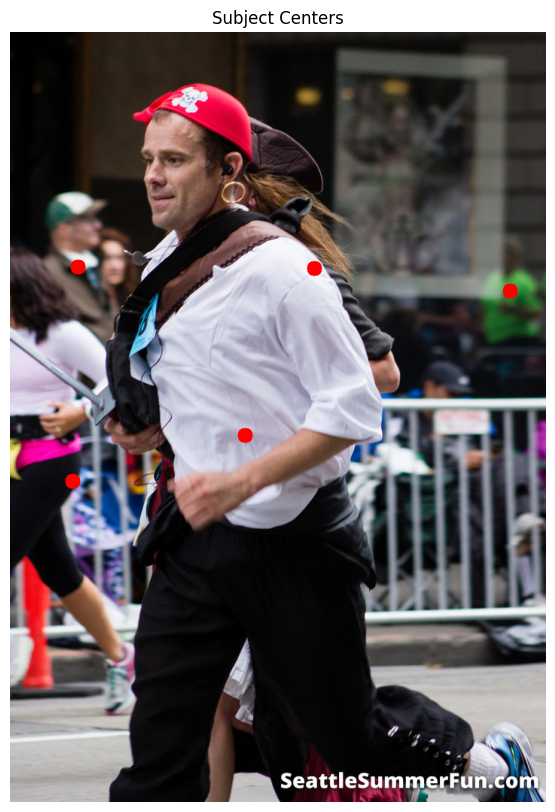

In [18]:
img_draw = img_rgb.copy()

for det in detections:

    cx = int(det["center_x"])
    cy = int(det["center_y"])

    cv2.circle(img_draw, (cx, cy), 10, (255,0,0), -1)

plt.figure(figsize=(10,10))
plt.imshow(img_draw)
plt.title("Subject Centers")
plt.axis("off")
plt.show()

In [19]:
image_area = w * h

for det in detections:

    normalized_area = det["area"] / image_area

    visual_weight = (
        normalized_area *
        det["confidence"]
    )

    det["visual_weight"] = visual_weight

detections

[{'class': 'person',
  'confidence': 0.8513220548629761,
  'x1': np.float32(121.10225),
  'y1': np.float32(58.31953),
  'x2': np.float32(504.31744),
  'y2': np.float32(1015.34705),
  'center_x': np.float32(312.70984),
  'center_y': np.float32(536.8333),
  'area': np.float32(366747.5),
  'thirds_distance': np.float32(164.16148),
  'visual_weight': np.float32(0.42823395)},
 {'class': 'person',
  'confidence': 0.8050627112388611,
  'x1': np.float32(0.0),
  'y1': np.float32(285.32013),
  'x2': np.float32(167.70773),
  'y2': np.float32(909.53955),
  'center_x': np.float32(83.85387),
  'center_y': np.float32(597.4298),
  'area': np.float32(104686.42),
  'thirds_distance': np.float32(175.55988),
  'visual_weight': np.float32(0.11559529)},
 {'class': 'person',
  'confidence': 0.6071149706840515,
  'x1': np.float32(623.2411),
  'y1': np.float32(272.96558),
  'x2': np.float32(705.8882),
  'y2': np.float32(415.89096),
  'center_x': np.float32(664.56464),
  'center_y': np.float32(344.42828),
  'ar

In [20]:
det_df = pd.DataFrame(detections)

det_df

,class,confidence,x1,y1,x2,y2,center_x,center_y,area,thirds_distance,visual_weight
0,person,0.851322,121.102249,58.319530,504.317444,1015.347046,312.709839,536.833313,366747.500000,164.161484,0.428234
1,person,0.805063,0.000000,285.320129,167.707733,909.539551,83.853867,597.429810,104686.421875,175.559875,0.115595
2,person,0.607115,623.241089,272.965576,705.888184,415.890961,664.564636,344.428284,11812.368164,189.923203,0.009836
3,person,0.595085,40.051022,211.723724,141.341873,413.165222,90.696449,312.444458,20404.179688,149.455475,0.016654
4,person,0.292444,290.027649,149.408173,518.809265,479.851501,404.418457,314.629822,75599.359375,75.152428,0.030324


In [21]:
save_path = r"C:\Users\bhanu\Downloads\StructCompose\data\annotations\sample_subjects.csv"

det_df.to_csv(save_path, index=False)

print("Saved subject annotations")

Saved subject annotations
